# ionique

### Nanopore signal analysis framework

In [1]:
# imports 
import ionique
import ionique.simple as iqs 
import ionique.plotting as iqp



session=ionique.datatypes.SessionFileManager()

In [2]:
iqs.panel_load_opt_files("~/Desktop/ionique_demo_data")

BokehModel(combine_events=True, render_bundle={'docs_json': {'721d7e40-2f2e-4857-9ca9-8a15a9daa777': {'version…

In [3]:
session.summary() # at any point this shows a summary of ranks and number of elements at each rank

{None: 1, 'file': 1, 'vstep': 640, 'vstepgap': 555}

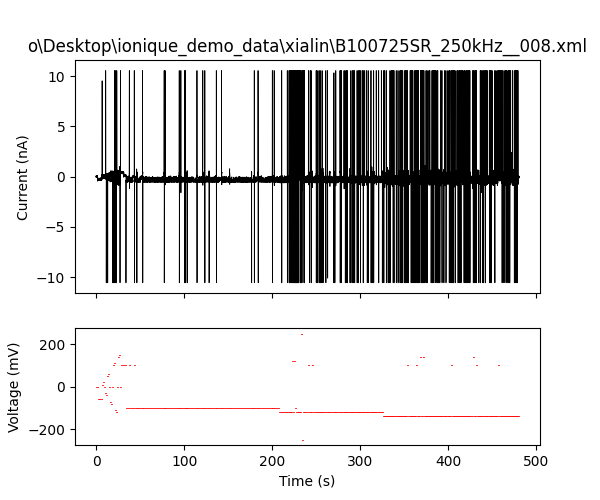

In [4]:
%matplotlib ipympl
iqp.qp_trace(plot_voltage="split",ranks=["file"],downsamples={"file":50})




In [6]:
# parse Events

iqs.panel_parser_AutoSquare()


BokehModel(combine_events=True, render_bundle={'docs_json': {'c949f6e3-7484-4d73-9801-3888cbba0810': {'version…

In [17]:
session.children[0].parse(parser=ionique.parsers.AutoSquareParser(threshold_baseline=0.6,expected_conductance=4.3,conductance_tolerance=1.2,wrap_padding=50),at_child_rank="vstepgap",newrank="event")


True

In [18]:
print(session.summary())

{None: 1, 'file': 1, 'vstep': 640, 'vstepgap': 555}


{None: 1, 'file': 1, 'vstep': 640, 'vstepgap': 555}


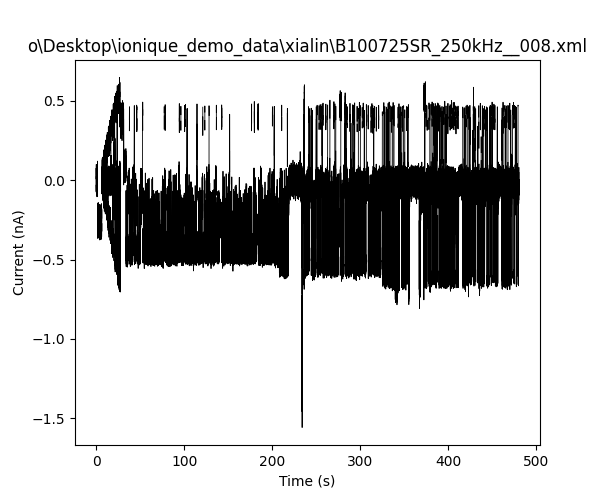

In [5]:
print(session.summary())
iqp.qp_trace()

In [13]:

iqs.panel_parser_SpeedyStatSplit()

BokehModel(combine_events=True, render_bundle={'docs_json': {'cd0f1999-3683-4377-90ee-5efe9c5bb413': {'version…

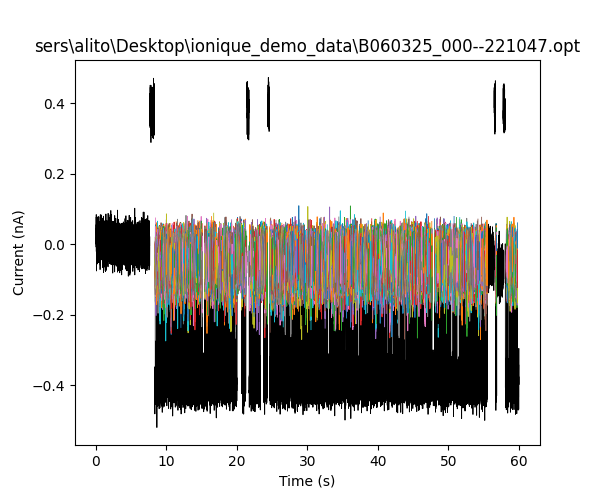

In [16]:
iqp.qp_trace(session.children[0],ranks=["vstepgap","subevent"],downsamples={"vstepgap":50,"subevent":1})

In [17]:
# extract features and preview the dataframe
feature_dataframe=iqs.get_standard_features()

print(feature_dataframe.info())
feature_dataframe.head()

<class 'pandas.core.frame.DataFrame'>
Index: 560 entries, 0 to 559
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   mean                  560 non-null    float64
 1   std                   560 non-null    float64
 2   frac                  560 non-null    float64
 3   duration              560 non-null    float64
 4   current               560 non-null    object 
 5   wrap                  560 non-null    object 
 6   start                 560 non-null    int64  
 7   filename              560 non-null    object 
 8   baseline              560 non-null    float64
 9   Voltage               560 non-null    int64  
 10  baseline_conductance  560 non-null    float64
 11  start_time            560 non-null    float64
 12  parent_start_time     560 non-null    float64
 13  subevent_starts       560 non-null    object 
 14  subevent_ends         560 non-null    object 
 15  subevent_mean         560 no

,mean,std,frac,duration,current,wrap,start,filename,baseline,Voltage,baseline_conductance,start_time,parent_start_time,subevent_starts,subevent_ends,subevent_mean,subevent_std,subevent_duration,subevent_count
0,-0.061785,0.034641,0.841951,0.02654,"[-0.06666536434884322, -0.10315907564643623, -...","[-0.40061704904382334, -0.43025023204500856, -...",421495,C:\Users\alito\Desktop\ionique_demo_data\B0603...,-0.390922,-200,1.954609,8.42990,8.3607,"[0, 11, 166, 177, 243, 255, 265, 270, 282, 313...","[11, 166, 177, 243, 255, 265, 270, 282, 313, 3...","[-0.08867344729986258, -0.057429663990901506, ...","[0.015538377175068209, 0.02882473411544059, 0....","[0.00019999999999953388, 0.0030799999999988614...",48
1,-0.048876,0.030956,0.876488,0.06284,"[-0.02978512349960125, -0.05545634949168467, -...","[-0.37446257117714793, -0.4226808830977922, -0...",422991,C:\Users\alito\Desktop\ionique_demo_data\B0603...,-0.395721,-200,1.978606,8.45982,8.3607,"[0, 24, 33, 38, 103, 113, 130, 137, 155, 172, ...","[24, 33, 38, 103, 113, 130, 137, 155, 172, 178...","[-0.06174262737943, -0.04709969033945118, -0.0...","[0.02840466713255658, 0.015192537465977438, 0....","[0.00045999999999857266, 0.0001599999999992718...",87
2,-0.049373,0.037040,0.872994,0.01380,"[-0.07117473782086764, -0.08621671820559301, -...","[-0.4016477678860859, -0.4594003005096846, -0....",429151,C:\Users\alito\Desktop\ionique_demo_data\B0603...,-0.388748,-200,1.943738,8.58302,8.3607,"[0, 22, 47, 75, 109, 114, 123, 136, 146, 157, ...","[22, 47, 75, 109, 114, 123, 136, 146, 157, 257...","[-0.06835344690242844, -0.04463642454069811, -...","[0.03117729469927953, 0.02393038808517614, 0.0...","[0.00042000000000008697, 0.0004799999999995918...",26
3,-0.056334,0.035201,0.857112,0.03162,"[-0.031492244180051046, -0.07278522830584566, ...","[-0.4046432947460999, -0.4320217821364029, -0....",429989,C:\Users\alito\Desktop\ionique_demo_data\B0603...,-0.394256,-200,1.971278,8.59978,8.3607,"[0, 45, 55, 205, 217, 287, 293, 298, 315, 327,...","[45, 55, 205, 217, 287, 293, 298, 315, 327, 38...","[-0.05361251151093219, -0.06676199308993852, -...","[0.030524460413351738, 0.01311122836828951, 0....","[0.0008799999999986596, 0.00018000000000029104...",61
4,-0.059008,0.034096,0.849092,0.03226,"[-0.0502383593875048, -0.05722788927718456, -0...","[-0.3965263840249995, -0.4130500977469064, -0....",435783,C:\Users\alito\Desktop\ionique_demo_data\B0603...,-0.391018,-200,1.955092,8.71566,8.3607,"[0, 128, 164, 170, 178, 211, 216, 235, 240, 26...","[128, 164, 170, 178, 211, 216, 235, 240, 262, ...","[-0.06346249671708004, -0.03165597391753976, -...","[0.031034318508778042, 0.0228864109519112, 0.0...","[0.0025399999999997647, 0.000700000000000145, ...",40


In [ ]:
iqp.dashboard_event_inspection(feature_dataframe)


In [ ]:
iqs.

In [19]:
# store the latest dataframe using a panel widget
iqs.panel_save_dataframe( start_dir="~")

# Alternatively, explicitly provide the dataframe to be saved
# iqs.panel_save_dataframe(feature_dataframe, start_dir="~")




BokehModel(combine_events=True, render_bundle={'docs_json': {'5a11ae4b-82a8-4e77-85be-7a5956ed2917': {'version…

In [22]:
%matplotlib inline


In [20]:
# DTW population distances
import numpy as np
from tslearn.metrics import cdist_dtw
def compute_distances(sampleset,**kwargs):

    means=list(sampleset.subevent_mean*1000)[:]
    # dwells=[np.log10(fine_dwell)+3 for fine_dwell in list(sampleset.fine_dwells)][:]
    stds=list(sampleset.subevent_std*1000)[:]

    data=list(np.array(np.stack(([mean,]),axis=-1)) for mean, std in zip(means,stds))
    
    precomputed=cdist_dtw(data,global_constraint="sakoe_chiba",sakoe_chiba_radius=20,n_jobs=10)
    return {"means":means,
            "stds":stds,
            "data":data,
            # "dwells":dwells,
            "distance_matrix":precomputed}
fine_df=feature_dataframe.copy()
fine_df["sample_type"]="MBP_D10"
# fine_df["fine_means"]=fine_df["subevent_mean"].apply(lambda x)

SEED=1
N_EVENTS=200
selected_df=fine_df.groupby("sample_type").sample(n=N_EVENTS,random_state=SEED)
dataset_dtw={}
for gp,_df in selected_df.groupby("sample_type"):
    dataset_dtw[gp]={"df":_df}
    dataset_dtw[gp].update(compute_distances(_df))

c:\Users\alito\AppData\Local\Programs\Python\Python313\Lib\site-packages\tslearn\bases\bases.py:15: UserWarning: h5py not installed, hdf5 features will not be supported.
Install h5py to use hdf5 features: http://docs.h5py.org/
  warn(h5py_msg)


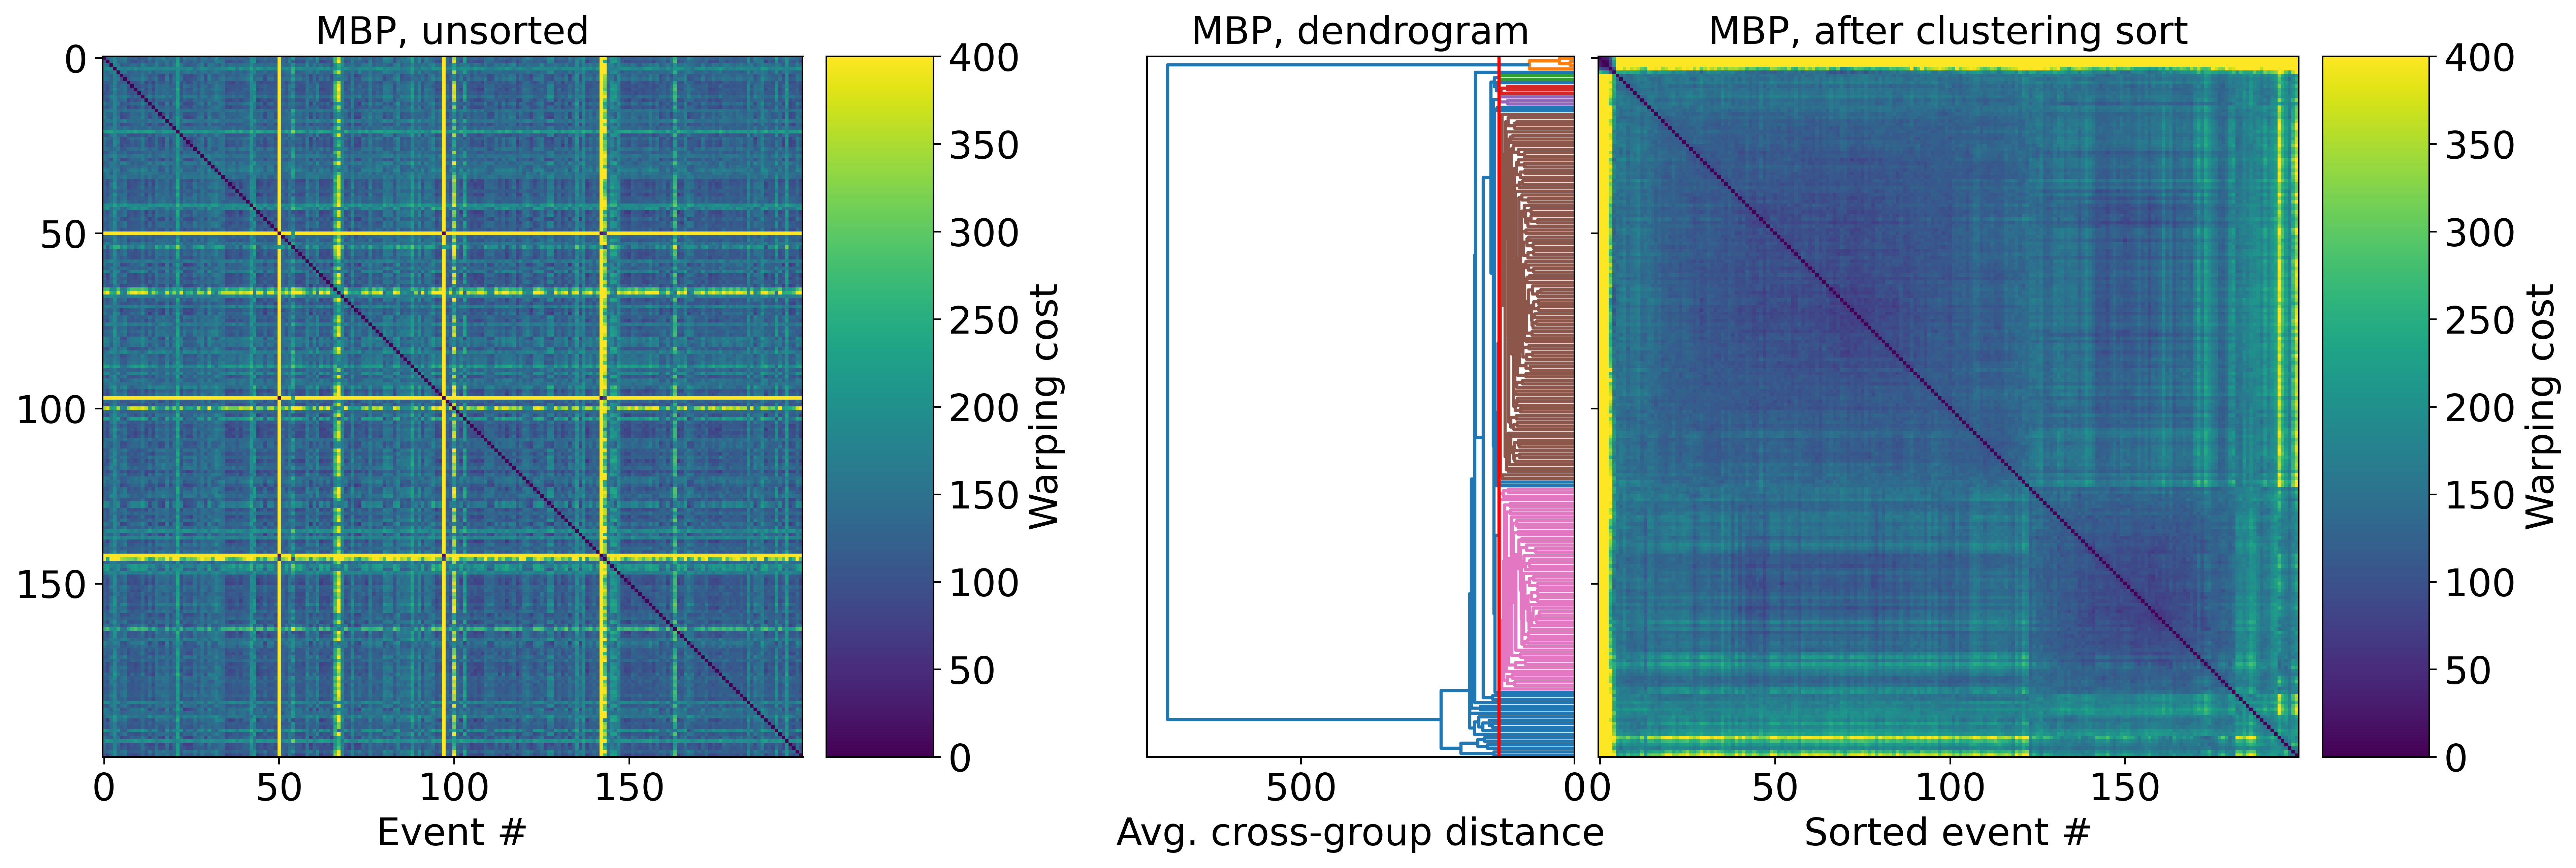

In [23]:
# DTW 
from scipy.cluster.hierarchy import linkage,dendrogram,optimal_leaf_ordering,leaves_list,cut_tree
from scipy.spatial.distance import squareform
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
# SEED=1
# N_EVENTS=100
# selected_df=fine_df.loc[fine_df["Voltage"]==-300].groupby("sample_type").sample(n=N_EVENTS,random_state=SEED)

map_names={"MBP_D10":"MBP",
           "MBP_P4":"RP1",
           "MBP_P3":"RP2",
           "MBP_P7":"RP3",
           "MBP_P6":"RP4"
           }

order_dict={"MBP":0,
            "RP1":1,
            "RP2":2,
            "RP3":3,
            "RP4":4}
def warping_pipeline_figs(subset_dict, identity,savefig=False,cut_level=0.85,vmin=0,vmax=100,**kwargs):

    # means=list(1000*sampleset.fine_means)[:]
    # dwells=[np.log10(fine_dwell)+3 for fine_dwell in list(sampleset.fine_dwells)][:]
    # stds=list(1000*sampleset.fine_stds)[:]

    # data=list(np.array(np.stack(([mean,std]),axis=-1)) for mean, std in zip(means,stds))
    
    # print(data)
    # precomputed=cdist_dtw(data,global_constraint="sakoe_chiba",sakoe_chiba_radius=20,n_jobs=10)
    # weight_factors=np.ones_like(precomputed)
    
    # for i in range(len(data)):
    #     for j in range(len(data)):
    #         M=len(data[i])+len(data[j])
    #         weight_factors[i,j]=1/M

    # precomputed*=weight_factors
    distance_matrix=subset_dict["distance_matrix"]

    
    plt.figure(figsize=(18,6),dpi=450)
    grid_spec=GridSpec(1,24,left=0.03,right=0.97,hspace=0.03,wspace=0)
    # plt.subplots(, sharey=True,constrained_layout=True,gridspec_kw={"wspace":})
    plt.subplot(grid_spec[0,0:7])
    im=plt.imshow(distance_matrix,vmin=vmin,vmax=vmax)
    
    ax = plt.gca()
    ax.set_xlabel("Event #",fontsize=18)
    ax.tick_params(axis="both", which="major", labelsize=18)
    
    plt.yticks(np.arange(200/50)*50,labels=np.arange(200//50)*50)
    # ax.tick_params(axis="both")
    plt.title(f"{map_names[identity]}, unsorted",fontsize=18)
    axcol=plt.subplot(grid_spec[0,7])
    cbar=plt.colorbar(im,label="Warping cost",cax=axcol)
    cbar.set_label("Warping cost", fontsize=18)	
    cbar.ax.tick_params(labelsize=18)
    # clust=OPTICS(min_samples=3,metric="precomputed",n_jobs=8,algorithm='brute',xi=0.2)
    # results=clust.fit_predict(precomputed)

    condensed=squareform(distance_matrix)
    results=linkage(condensed,method='average',optimal_ordering=True)

    # cutline=np.median(branching_distances)+np.std(branching_distances)
    branching_distances=results[:,2]
    cutline=np.quantile(branching_distances,cut_level)
    # print(results)
    # print(len(results))
    # plt.figure()
    ax_dend=plt.subplot(grid_spec[0,10:14])
    dn=dendrogram(optimal_leaf_ordering(results,condensed),color_threshold=cutline,orientation='left',no_labels=True)#,truncate_mode="level",orientation='left',p=9)
    # for artist in ax_dend.lines:
    #     artist.set(lw=0.5)

        
    
    plt.title(f"{map_names[identity]}, dendrogram",fontsize=18)
    plt.xlabel("Avg. cross-group distance",fontsize=18)
    ax_dend.tick_params(axis="both", which="major", labelsize=18)
    ax_dend.set_ylim(ax_dend.get_ylim()[::-1])
    
    # plt.subplot(1,3,3)
    # plt.hist(branching_distances)
    
    cut=cut_tree(results,height=cutline)
    print(results)
    cut=[int(c[0]) for c in cut]
    group_ids=set(cut)

    

    plt.axvline(cutline,c="r")

    
    
    # plt.axvline(cutline,label=cutline)
    # plt.legend()
    # return
    clustered_data=[[] for _ in range(len(group_ids))]
    clustered_idx=[[] for _ in range(len(group_ids))] 
    clustered_rows=[[] for _ in range(len(group_ids))] 
    for i,(group_id,event,row) in enumerate(zip(cut,subset_dict["data"],subset_dict["df"].iterrows())):
        clustered_data[group_id].append((i,event))
        clustered_rows[group_id].append(row)
        # clustered_idx[group_id].append()
    # plt.subplot()
    # for id,group in enumerate(clustered_data):
    #     print("Group", id)
    #     for event_idx,event in group:
    #         print("  ",event_idx)
    # print(cut)

    # print(dn)
    # print(clust.ordering_)
    reordered_idx=leaves_list(optimal_leaf_ordering(results,condensed))
    # print(reordered_idx)
    reordered_matrix=np.zeros_like(distance_matrix)
    for new_position,original_position in enumerate(reordered_idx):
        for new_position_j,original_position_j in enumerate(reordered_idx):
            reordered_matrix[new_position,new_position_j]=distance_matrix[original_position,original_position_j]

    # plt.figure()
    axim=plt.subplot(grid_spec[0,14:21])
    im=plt.imshow(reordered_matrix,vmin=vmin,vmax=vmax)
    axim.set_xlabel("Sorted event #", fontsize=18)
    axim.tick_params("x",labelsize=18)
    plt.yticks(np.arange(200/50)*50,labels="")
    plt.title(f"{map_names[identity]}, after clustering sort",fontsize=18)
    axcol=plt.subplot(grid_spec[0,21])
    cbar=plt.colorbar(im,label="Warping cost",cax=axcol)
    cbar.set_label("Warping cost", fontsize=18)	
    cbar.ax.tick_params(labelsize=18)
    # print(clust.metadata_routing_)
    if savefig:
        plt.savefig(f"clustering_exports/Clustering_results_{identity}_paper.pdf",dpi=300,bbox_inches="tight")
    output={
        "condensed_distance_matrix":condensed,
        "linkage":results,
        "cut_level":cutline,
        "clustered_rows":clustered_rows,
        "reordered_idx":reordered_idx,
        "reordered_distance_matrix":reordered_matrix,
        "clustered_data":clustered_data,

    }
    return output

for gp,subset_dict in dataset_dtw.items():

    clustering_dict=warping_pipeline_figs(subset_dict,gp,cut_level=0.85,vmax=400,savefig=False)
    subset_dict.update(clustering_dict)
    # break
    # break



MBP_D10 30 86


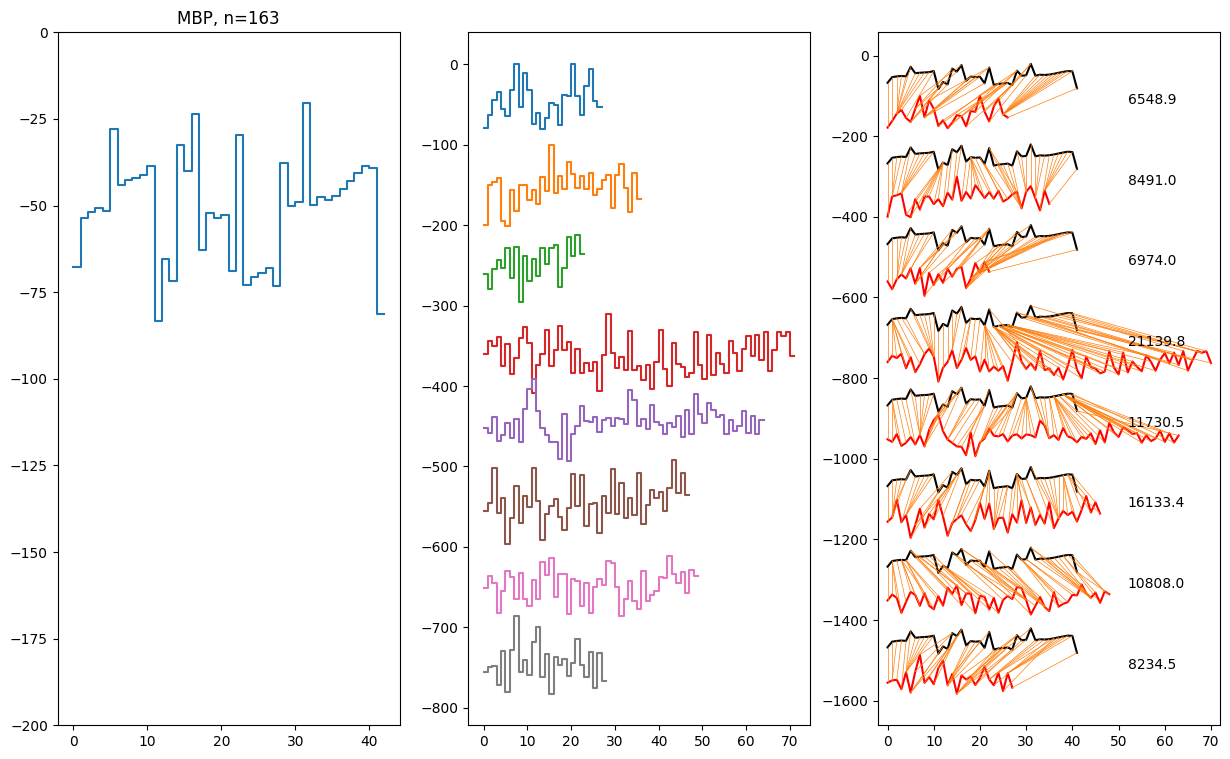

In [24]:
# barycenter averaging

from tslearn.barycenters import dtw_barycenter_averaging,softdtw_barycenter
from tslearn.metrics import dtw_path,dtw_path_from_metric,soft_dtw_alignment
def shorten_signal(signal, target_length):
    if signal.shape[0] <= target_length:
        return signal
    
    diff=np.abs(np.diff(signal,prepend=[np.inf],axis=0))
    min_idx=np.argmin(diff)
    # print(np.concatenate([barycenter[:min_idx],barycenter[min_idx+1:]],axis=0))
    return shorten_signal(np.concatenate([signal[:min_idx-1],[np.mean(signal[min_idx-1:min_idx+1],axis=0)],signal[min_idx+1:]],axis=0),target_length=target_length)

def dba_pipeline(subset_dict,identity,save_fig=False):
    clustered_data=subset_dict["clustered_data"]
    processed_barycenters={}
    events=[]
    for id,group in enumerate(clustered_data):
        if len(group)<30:
            continue
        events+=[event for _,event in group]
    median_length=int(np.median([event.shape[0] for event in events]))
    
    # reselected_events=

    # for event_idx,event in group:
        # print("  ",event_idx)
    # barycenter=dtw_barycenter_averaging(events,max_iter=2000,tol=1e-9,n_init=5,metric_params={"sakoe_chiba_radius":30})
    print(identity,id,max([len(event )for event in events]))
    # barycenter=softdtw_barycenter(events,max_iter=5000,tol=1e-8,gamma=500)
    barycenter_clean=[]
    if identity=="MBP_P6" or identity=="MBP_P7":
            gamma=3*median_length
            barycenter=softdtw_barycenter(events,max_iter=10000,tol=1e-9,gamma=gamma)  
    else:
            gamma=5*median_length
            barycenter=softdtw_barycenter(events,max_iter=5000,tol=1e-8,gamma=gamma)
    barycenter=shorten_signal(barycenter[:,0],target_length=median_length)
    # barycenter=barycenter[:,0]
    sample_events=events[50:65:2]    
    for row in barycenter: #drop consecutive duplicates 
        # if (len(barycenter_clean)>0) and (barycenter_clean[-1][0]== row[0]):
        #     continue
        barycenter_clean.append(row)
    barycenter_clean=np.array(barycenter_clean)
    # barycenter=softdtw_barycenter(events,max_iter=200,tol=1e-7,gamma=0.2)
    plt.figure(figsize=(15,9))
    # print(len(barycenter[:,0]))
    # print(barycenter[1])
    plt.subplot(1,3,1)
    barycenter_steps=np.empty((barycenter_clean.shape[0]*2))
    barycenter_steps[0::2]=barycenter_clean
    barycenter_steps[1::2]=barycenter_clean
    
    # barycenter_clean=barycenter_steps                  
    # barycenter_clean=np.concatenate([*([step]+[step]) for step in barycenter_clean])#np.stack((barycenter_clean,barycenter_clean),axis=2).reshape(len(barycenter_clean)*2,2,order='A').ravel().reshape(len(barycenter_clean)*2,2,order='C')
    # print(barycenter_clean)
    tt=(np.arange(len(barycenter_steps[:]))+1)//2
    
    plt.plot(tt,barycenter_steps[:])

    plt.title(f"{map_names[identity]}, n={len(events)}")
    
    # plt.fill_between(tt,barycenter_steps[:]+barycenter_steps[:],barycenter_steps[:,0]-barycenter_steps[:,1],facecolor='tab:blue',alpha=0.3)
    plt.ylim(-200,0)
    plt.subplot(1,3,2)
    yoffset=0
    # print(barycenter_clean)
    for steps in sample_events:
        square_steps=np.vstack((yoffset+steps[:,0],yoffset+steps[:,0])).transpose().ravel()
        
        t=(np.arange(len(square_steps))+1)//2
        
        # print(t)
        plt.plot(t,square_steps)
        yoffset-=100
    plt.subplot(1,3,3)
    yoffset=0
    for steps in sample_events:
        # warping_path,similarity=dtw_path(steps,barycenter_clean,sakoe_chiba_radius=20)
        dist_matrix,dist=soft_dtw_alignment(steps,barycenter,gamma=0.1*len(barycenter),)
        warping_path,_cost=dtw_path_from_metric(1-dist_matrix, metric="precomputed",global_constraint="itakura",itakura_max_slope=10)
        
        plt.plot(barycenter_clean[:]+yoffset,c='k')
        yoffset-=100
        plt.plot(steps[:,0]+yoffset,c='r')
        for pair in warping_path:
            plt.plot([pair[0],pair[1]],[steps[pair[0],0]+yoffset,barycenter_clean[pair[1]]+yoffset+100],lw=0.5,c='tab:orange')
        yoffset-=100
        plt.text(len(barycenter_clean[:])+10,yoffset+80,f"{dist:.1f}")
    plt.xlim(-2,len(barycenter_clean[:])+30)
    processed_barycenters[id]={"barycenter_clean":barycenter_clean,
                                "barycenter_steps":barycenter_steps,
                                "barycenter_steps_t":tt,
                                "dataset_used":events}
    # plt.savefig(f"figure_exports_AF/SI_Barycenters_alignment_sim_{map_names[identity]}_g{gamma}.pdf")
    return processed_barycenters
for gp,subset_dict in dataset_dtw.items():
    processed_barycenters=dba_pipeline(subset_dict,gp,save_fig=False)
    # clustering_dict=warping_pipeline(subset_dict,gp,savefig=True)
    subset_dict.update({"barycenter_info":processed_barycenters})
    # break

In [25]:
# imports
from tslearn.metrics import soft_dtw_alignment,gamma_soft_dtw,dtw_path_from_metric
def calculate_warping_repr(source, target,path):
    # assert len(target)>=len(source)
    def purge_pile(pile):
        p0=[p[0] for p in pile]
        p1=[p[1] for p in pile]
        t_pile=[]
        source_idxs=[]
        target_idxs=[]
        # val_pile=[]
        if len(pile)==1:
            t_pile=[p1[0]-0.5,p1[0]+0.5]
            source_idxs+=[p0[0],p0[0]]
            target_idxs+=[p1[0],p1[0]]
            # return t_pile
        if len(pile)>1:
            if p0[0]==p0[1]:
                pile_output="extend"
                for (p0point,p1point) in pile:
                    t_pile+=[p1point-0.5,p1point+0.5]
                    source_idxs+=[p0point,p0point]
                    target_idxs+=[p1point,p1point]

            elif p1[0]==p1[1]:
                pile_output="squeeze"
                n=len(pile)
                factor=1/(n)
                for i,(p0point,p1point) in enumerate(pile):
                    # t_pile+=[p1point-0.5,p1point+0.5]
                    t_pile+=[p1point-0.5+i*factor,p1point-0.5+(i+1)*factor]
                    source_idxs+=[p0point,p0point]
                    target_idxs+=[p1point,p1point]

            else:
                print("what the hell?",pile)
        return t_pile,source_idxs,target_idxs
    pile=[]
    t_total=[]
    source_idxs=[]
    target_idxs=[]
    last=None
    for i,path_pair in enumerate(path):
        if last is not None:
            if path_pair[0]==last[0] or path_pair[1]==last[1]:
                pile.append(path_pair)
                last=path_pair
            else:
                purge_result=purge_pile(pile)
                t_total+=purge_result[0]
                source_idxs+=purge_result[1]
                target_idxs+=purge_result[2]
                pile=[path_pair]
                last=path_pair
        else:
            pile=[path_pair]
            last=path_pair
    
    purge_result=purge_pile(pile)
    t_total+=purge_result[0]
    source_idxs+=purge_result[1]
    target_idxs+=purge_result[2]
    warped_source=[ source[idx] for idx in source_idxs]
    t_target=[]
    stepped_target=[]
    for i,target_val in enumerate(target):
        t_target+=[i-0.5,i+0.5]
        stepped_target+=[target_val,target_val]
    
    return np.array(t_total),np.array(source_idxs),np.array(target_idxs),np.array(warped_source),np.array(t_target),np.array(stepped_target)
def score_insertions_deletions(path):
    # goal is to assign a score of insertions and deletions seen at a specific point on the target, not the source.
    # insertions mean that the source has >1 points that match one point on the target. Denoted by a positive output
    # deletions mean that the source has a point that matches >1 point on the target. Denoted by a negative output
    score_list=[] #length of the   
    n_target=path[-1][1]+1 #length of the target
    last=[None,None]
    for source_pt, target_pt in path:
        if target_pt>=len(score_list):
            if last[0] == source_pt:
                score_list[-1]-=1
                score_list.append(0)
            else:
                score_list.append(0)
            last=[source_pt,target_pt]
            # print( "advanced at ",source_pt,target_pt)
        else:
            if last[1]==target_pt:
                score_list[-1]+=1
            last=[source_pt,target_pt]
                
    # print(*score_list)
    # print(path)
    insertion_list=[max (val,0) for val in score_list]
    deletion_list=[min(val,0) for val in score_list]

    # print(insertion_list)
    # print(deletion_list)
    return insertion_list, deletion_list, score_list
test_path=[(0,0),
           (1,1),
           (2,1),
           (3,1),
           (4,2),
           (4,3),
           (4,4),
           (5,5),
           (6,6),
           (6,7),
           (7,8),
           (8,8),
           (9,9),
           (10,10)
           ]

# print(*[t[0] for t in test_path])
# print(*[t[1] for t in test_path])

results=score_insertions_deletions(test_path)
# print(*results[2])

# print(results)
test_path=[(0,0),
           (1,1),
           (2,1),
           (3,1),
           (4,2),
           (4,3),
           (4,4),
           (5,5),
           (6,6),
           (6,7),
           (7,8),
           (8,8),
           (9,9),
           (10,10)
           ]
results=calculate_warping_repr([0,1,0,0,0,0,0,1,2,3,4],[0,1,1,2,0,0,0,1,2,0,0],test_path)
# print(len(results[-1]))



30 163
   30
dict_keys(['barycenter_clean', 'barycenter_steps', 'barycenter_steps_t', 'dataset_used'])
7


Text(0.5, 0.01, 'Segment index\n(warped to barycenter)')

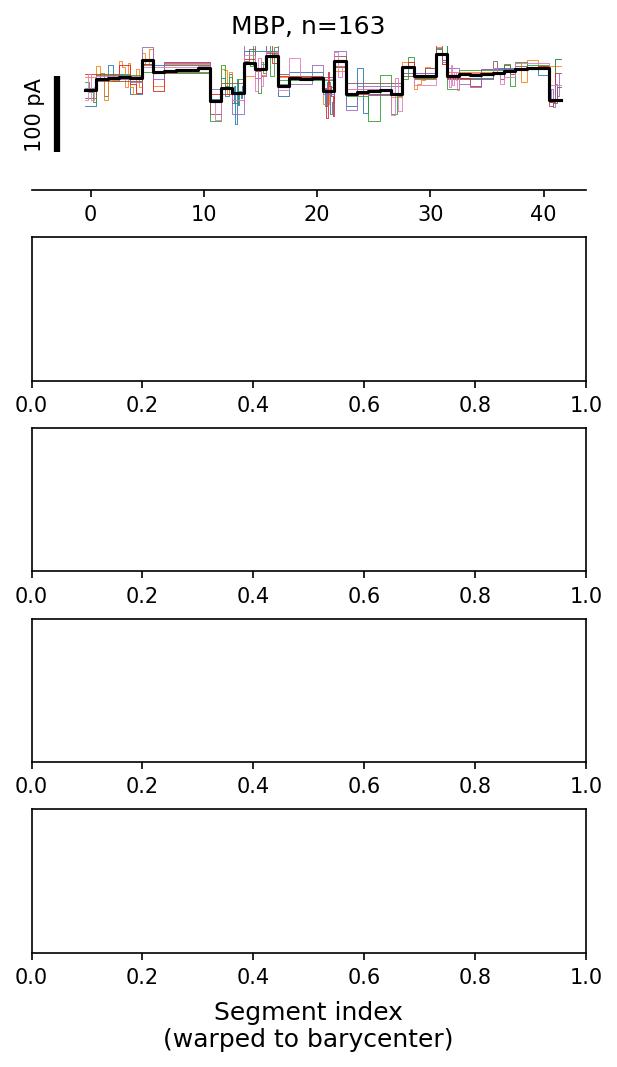

In [26]:
# plot aligned barycenters
# map_names={"MBP_D10":"MBP",
#            "MBP_P4":"RP1",
#            "MBP_P3":"RP2",
#            "MBP_P7":"RP3",
#            "MBP_P6":"RP4"
#            }

# order_dict={"MBP":0,
#             "RP1":1,
#             "RP2":2,
#             "RP3":3,
#             "RP4":4}

fig15,axs15=plt.subplots(nrows=5,ncols=1,num=105,figsize=(4,7),dpi=150,constrained_layout=True,gridspec_kw={"wspace":0},sharey=True,clear=True)
for sample_type, subset_dict in dataset_dtw.items():
    # print(*subset_dict.keys(),sep='\n')
    for group_id,group_values in subset_dict["barycenter_info"].items():
        if type(group_id) is not int and group_id.startswith("sub"):
            continue
        print(group_id,len(group_values["dataset_used"]))
        ax=axs15[order_dict[map_names[sample_type]]]
        print("  ",group_id)
        print(group_values.keys())
        
        # median_length=int(np.median([event.shape[0] for event in group_values["dataset_used"]]))
        # print(group_values["dataset_used"])
        # trimmed_events=[shorten_signal_by_deviation(event[:,0],deviation_threshold=5) for event in group_values["dataset_used"]]
        events=group_values["dataset_used"]
        # median_length=int(np.median([event.shape[0] for event in trimmed_events]))
        sample_events=events[55:100:7]
        print(len(sample_events))
        # sample_events=[event[:,0] for event in sample_events]
        # if sample_type=="MBP_P6":
            # barycenter=softdtw_barycenter(trimmed_events,max_iter=10000,tol=1e-9,gamma=4*median_length)  
        # else:
            # barycenter=softdtw_barycenter(trimmed_events,max_iter=5000,tol=1e-8,gamma=5*median_length)
        n=len(events)
        barycenter=group_values["barycenter_clean"]
        # print(sample_type, median_length)
        warping_paths=[]
        # figsep=plt.figure(figsize=(6,2.5))
        ygap=0
        for sample_event in sample_events:
            dist_matrix,dist=soft_dtw_alignment(sample_event,barycenter,gamma=0.1*len(barycenter),)
            warping_path,_cost=dtw_path_from_metric(1-dist_matrix, metric="precomputed")#,global_constraint="itakura",itakura_max_slope=10)
            warping_results=calculate_warping_repr(sample_event,barycenter,warping_path)
            ax.plot(warping_results[0],warping_results[3][:]+ygap,alpha=1,lw=0.4)
            ygap-=0
            # for tpair,valpair in zip(zip(warping_results[0][::2],warping_results[0][1::2]),zip(warping_results[3][::2,0],warping_results[3][1::2,0])):
            #     plt.plot(tpair,valpair)
        
        
        
        ax.plot(warping_results[4],warping_results[5][:],c='k')
        
        ax.set_title(map_names[sample_type]+f", n={n}")
        ax.set_ylim(-200,-10)
        ax.spines[["top","right","left"]].set_visible(False)
        ax.set_yticks([])
        
axs15[0].plot([-3,-3],[-50,-150],c='k',lw=3,solid_capstyle='butt')

axs15[0].text(-4,-100,f"{100:.0f} pA",ha="right", va="center",rotation=90)
fig15.supxlabel("Segment index\n(warped to barycenter)")
# fig15.savefig(f"figure_exports_AF/barycenter_self_aligned_Fig4_v4p.pdf",bbox_inches="tight")

        # axs102[0]
        # print(warping_path,_cost,dist)
        # suggested_gamma=gamma_soft_dtw(group_values["dataset_used"],n_samples=9000,random_state=0)/max([len(group_values["dataset_used"])])
        # print("suggested_gamma:",suggested_gamma)
        
        # new_barycenter=softdtw_barycenter(group_values["dataset_used"],max_iter=5000,tol=1e-8,gamma=suggested_gamma)
        # plt.figure()
        # plt.plot(barycenter)
        
        # plt.plot(new_barycenter)
        # plt.figure()
        # ax=plt.imshow(dist_matrix)
        # plt.colorbar(mappable=ax)
        # print(dist_matrix)
        # plt.plot([j for (i, j) in warping_path], [i for (i, j) in warping_path], "w-",
        #      linewidth=1)
        # yoffset=0
        # plt.figure()
        # plt.plot(sample_event[:,0]+yoffset,c='r')
        # yoffset-=100
        # plt.plot(barycenter[:,0]+yoffset,c='k')
        # for pair in warping_path:
        #     plt.plot([pair[0],pair[1]],[sample_event[pair[0],0]+yoffset+100,barycenter[pair[1],0]+yoffset],lw=0.5,c='tab:orange')
        
        

In [ ]:
# interactive jupyter dashboard for exploring and clicking on events of ionic current
# options: 1. grouping (categorical color in scatterplot) [None or specific non-array columns] 2. x and y of the scatter plot from specified columns (non-array columns) 3. x and y logscale checkboxes for the scatterplot. 
 
# event selection: either by clicking on the point on scatterplot or by a form entry containing an up down arrow and manual number input refering to row in the array. deselction must be allowed. only one selected at a time.
# scatter visualization: selected event must be boldened in the scatterplot and immediately shown in the event view. 
# blockade event view: In the figure panel displaying the event current, the selected event current is an array in the cells in "wrap" column. the x axis must autoscale for every new event. y autoscale must only be done if a checkbox is clicked (default on). 
# sampling_frequency : df "start"/ df "start_time"
# the wrap column is the same as current column, but with some datapoints padded on either side. to find the offset time between the start of the values in wrap and values in current column, try to match the values in the current to values in wrap for every selected event. once a match is found, add the identified negative offset to "start" to find the start time of the wrap array. construct the x (time) array using this and sampling frequency.
# if a checkbox saying show sub-segments is checked, use the arrays in columns "subevent_start" and "subevent_end" (paired values) to plot cyclically colored current segments.
# if the show sub-segments checkbox is unchecked, then plot the wrap in black and main event current in blue.


In [ ]:
# Inspect parsed events by plotting the trace
ionique.plotting.qp_trace(session.children[0],ranks=["vstepgap","event"])

In [ ]:
# inspect scatter plot
ionique.plotting.qp_scatter(session,x="duration",
                            y="frac",
                            hue="voltage",
                            logscale="x",
                            figsize=(3,3))


In [ ]:
# Segment events with bayesian segmenter
segmenter=ionique.parsers.SpeedyStatSplit(
    250000,
    min_width=5,
    max_width=10000,
    window_width=1000,
    prior_segments_per_second=5000)

session.parse(segmenter, at_child_rank="event",newrank="subevent")


In [ ]:
dataframe= ionique.utils.extract_features(session,bottom_rank="subevent",automatic_features=True)

dataframe.info()

In [ ]:
# Save the dataframe to a file through a dialog box, allows for pickle, excel, csv, etc.
# Allows for unchecking columns 
dataframe.save_GUI()

### Additional functions to include:
    - ML
      - Basic DTW barycenter averaging
      - Basic classification
    - Nicer plotting example snippets on the docs page
- 

In [ ]:

import tkinter as tk
from tkinter import ttk
root = tk.Tk(); root.withdraw()
t = tk.Toplevel(root); ttk.Label(t, text="Hello Tk").pack(padx=20, pady=20)

In [ ]:
# # Run this cell to import libraries and modules

# import ionique.core as ct
# from ionique.io import EDHReader, OPTReader
# import ionique.datatypes as dt
# from ionique.utils import Trimmer, Filter
# from ionique.utils import extract_features
# from ionique.parsers import  AutoSquareParser
# import os
# import pandas as pd
# import numpy as np
# import glob
# import matplotlib.pyplot as plt
# import seaborn as sns
# # from scipy import signal
# # import inspect
# # from scipy.signal import find_peaks

# ! pip install pyqt6
# import panel as pn
# pn.extension()

## Upload files

#### in this demo we focus on the Axopatch output XML, _volt.opt files with timestamps, voltages, and corresponding opt files with the current data

### Step 1: 
Open a folder with the data, select .opt files to be analyzed

In [ ]:
# Run this cell to select the files


file_browser = pn.widgets.FileSelector(directory="~", file_pattern="*.opt")
file_browser

In [ ]:
file_browser.value

# Observe current and voltage. Raw data

To take a look at the raw data, current alinged to voltage, you can modify the following parameters:


Voltage compress: 

Downsample:


In [ ]:
## Run this cell. It will open the window for the parameter modifications

voltage_compress_checkbox = pn.widgets.Checkbox(name="Voltage Comress", value=True)
downsample_input = pn.widgets.IntInput(name="Downsample", value=5, step=1, start=1)
run_button = pn.widgets.Button(name="Ok")
form = pn.Column(pn.pane.Markdown("OPTReader Parameters for initial investigation of Voltage Steps"), voltage_compress_checkbox, downsample_input, run_button)
form

### Run the following cell to plot the current against the time with an aligned voltage

The plots will be saved in the folder "snapshots".

In [ ]:
## Run this cell
for file in file_browser.value[0:1]: 
    print(file)
    metadata, current, voltage = OPTReader(file, voltage_compress=True, downsample=1)
    sampling_frequency = metadata['Sampling frequency (SR)']
    time = np.linspace(0, len(current) / sampling_frequency, num=len(current))
    voltage_ = np.zeros(len(current))
    for (start, end), value in voltage:
        voltage_[start:end] = value
        
    # adjust plot size here if needed 
    fig, ax1 = plt.subplots(figsize=(12, 6))
    
    ax1.plot(time, current, lw=0.3, c='k', label='Current')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Current (nA)', color='k')
    ax1.tick_params(axis='y', labelcolor='k')
    
    ax2 = ax1.twinx()
    ax2.plot(time, voltage_, lw=0.5, c='r', label='Voltage')
    ax2.set_ylabel('Voltage (mV)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    file_name = metadata["HeaderFile"].split("/")[-1]
    plt.title(f"Current and Voltage Plot for {file_name}")
    
    
    # fig.savefig(os.path.join("snapshots", os.path.splitext(os.path.split(metadata["HeaderFile"])[-1])[0]+".png"), bbox_inches="tight")
   


# Select files

### Step 2.

##### Now when you have plotted the current, take a look at the traces and in the Documents window manually deselect the documents  that you want to skip in the analysis in the previous step (the notebook will automatically update the list of files)




# Observe preprocessed files

## Extract metadata, current and voltage from the input file with the parameters:

*voltage_compress* is a boolean parameter.
* True voltage data is compressed and represented in a summarized format (list of start and end points for each voltage step)
* False voltage is a full array

*downsample* is the factor by which the data is downsampled. 
* downsample=1: all data points are preserved.
* downsample=10: every 10th data point is retained, reducing data size.

*prefilter*: apply the following filters of on the data: 

* Low-pass filters: Remove high-frequency noise.
* High-pass filters: Remove baseline drifts or low-frequency artifacts.
* Band-pass filters: Retain a specific frequency range for analysis.
* Band-stop filters:

  define the method:
  filter_method:

  * butter, bessel
   
* Samples to remove

In [ ]:
## Run this cell!

voltage_compress_2 = pn.widgets.Checkbox(name="Voltage Compress", value=True)
downsample_input_2 = pn.widgets.IntInput(name="Downsample", value=5, step=1, start=1)
cutoff_frequency = pn.widgets.IntInput(name="Cutoff Frequency", value=25000)
sampling_frequency = pn.widgets.IntInput(name="Sampling Frequency", value=250000)
filter_type = pn.widgets.Select(name="Filter type", options=["lowpass", "highpass", "bandpass", "bandstop"])
filter_method = pn.widgets.Select(name="Filter method", options=["bessel", "butter"])
order = pn.widgets.IntInput(name="Order",  value=2, step=1, start=1)
direction = pn.widgets.Checkbox(name="Bidirectional", value=True)
samples_remove = pn.widgets.IntInput(name="Samples to Remove", value=100)
run_button = pn.widgets.Button(name="Ok")
form_2 = pn.Column(pn.pane.Markdown("OPTReader Parameters for Preprocessing data"), cutoff_frequency, sampling_frequency, voltage_compress_checkbox, downsample_input, filter_type, filter_method,
                   order, direction, samples_remove, run_button)
form_2

In [ ]:
## Run this cell!

filt = Filter(
    cutoff_frequency=voltage_compress_2.value,
    filter_type=filter_type.value,
    filter_method = filter_method.value,
    bidirectional=direction.value,
    sampling_frequency=sampling_frequency.value, 
    order=order.value,
)
trimmer=Trimmer(samples_to_remove=samples_remove.value)

In [ ]:
# Apply filters
sfm = dt.SessionFileManager()
sfm.clear_children()
sampling_frequency= sampling_frequency.value
downsample=downsample_input_2.value
for datafile in file_browser.value[0:1]:
    print(datafile)
    metadata, current, voltage = OPTReader(datafile, voltage_compress=voltage_compress_2.value, downsample=downsample_input_2.value, prefilter=filt)
    metadata['eff_sampling_freq'] = sampling_frequency / downsample

    trace_file = dt.TraceFile(
        current=current,
        voltage=voltage,
        parent=sfm,
        metadata=metadata,
        unique_features={
            "sampling_freq": metadata["eff_sampling_freq"],
            "eff_sampling_freq": metadata["eff_sampling_freq"]
        }
    )

    trimmer(trace_file)

    for segment in trace_file.traverse_to_rank("vstepgap"):
        event_parser = AutoSquareParser(threshold_baseline=0.7,expected_conductance=2,conductance_tolerance=1.15,wrap_padding=50,rules=[lambda event:event.duration>4])

        segment.parse(parser=event_parser, newrank="event")
        df = extract_features(segment, bottom_rank='event',
             extractions=['mean', 'frac', 'duration', 'baseline', 'current', 'wrap', 'start'],
             add_ons={"sample_type": "MBP_D10"},
             lambdas={"Voltage": lambda segment: int(1000 * segment.get_feature("voltage")),
                      "start_time": lambda seg: segment.start / segment.get_feature("eff_sampling_freq")})
        

In [ ]:
df

In [ ]:
filter_type

## Conductance plot

In [ ]:
 # Conductance in nS
%matplotlib inline
for i, tf in enumerate(sfm.children):
    fig, (ax0, ax1) = plt.subplots(2, 1, sharex=True, num=i+1, 
                                   gridspec_kw={'height_ratios': [3, 1]}, figsize=(7, 7))
    for child in tf.traverse_to_rank("vstepgap"):
        voltage = child.get_feature("voltage")
        if voltage > 0:  
            conductance = child.current  / voltage 
            ax0.plot(child.time, conductance, lw=0.3, c='k') 
            ax1.plot([child.time[0], child.time[-1]], [voltage] * 2, lw=0.6, c='k')
    #file_name = tf.get_feature("metadata")["HeaderFile"].split("/")[-1]
    #plt.title(f"Conductance for {file_name}")
    ax0.set_ylabel("Conductance (nS)")
    ax1.set_ylabel("Voltage (mV)")
plt.tight_layout()
plt.show()

## Curent and voltage steps

In [ ]:
%matplotlib qt
for i, tf in enumerate(sfm.children):
    fig, ax1 = plt.subplots(figsize=(12, 6))
    ax2=ax1.twinx()
    for child in tf.traverse_to_rank("vstep"):
        ax1.plot(child.time, child.current, lw=0.3, label='Current')
        ax2.plot([child.time[0],child.time[-1]], [child.unique_features['voltage']]*2, lw=0.5, c='r')
        #file_name = tf.get_feature("metadata")["HeaderFile"].split("/")[-1]
        #plt.title(f"Current and Voltage Plot for {file_name}")
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Current (nA)', color='k')
    ax1.tick_params(axis='y', labelcolor='k')
    ax2.set_ylabel('Voltage (mV)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    plt.tight_layout()
    plt.show()


# Start event parser

In [ ]:
import numpy.ma as ma
from ioniq.parsers import lambda_event_parser
plt.close('all')
color_map={80.0:"tab:grey",60:"tab:blue",150:"tab:green",90:"tab:orange",120.0:"tab:red",100:"tab:purple"}
def parse(tf,starts=None,ends=None,voltage_range=(0.149,0.251),threshold=0.7):
    if starts is None:
        starts=[tf.time[0]]
    if ends is None:
        ends=[tf.time[-1]]
    
    steps=set()
    # print(len(tf.traverse_to_rank("vstepgap")))
    for step in tf.traverse_to_rank("vstepgap"):
        for start,end in zip(starts,ends):
            # print(step.get_feature('voltage'))
            if start<step.time[0] and step.time[-1]<end and voltage_range[0]<=step.get_feature("voltage")<=voltage_range[1]:
                steps.add(step)
    if len(steps)==0:
        return
    steps=list(steps)
    # plt.figure()
    ti=0
    results=[]
    for step in steps:
        # plt.plot(step.t,step.current,c='k',lw=0.4)
        mask=np.where(step.current>100e-3,1,0)
        masked_current=ma.masked_array(step.current,mask)
        
        hist,edges=np.histogram(masked_current,bins=150,range=(50e-3,900e-3))
        centers=edges[:-1]+(edges[1]-edges[0])*0.5
        I0guess=centers[np.argmax(hist)]

        Ithresh=I0guess*threshold

        if I0guess<150e-3:
            continue
        eventmask=np.where(step.current<Ithresh,1,0)
        lambda_parser=lambda_event_parser(threshold=Ithresh,rules=[lambda event:0<event.mean<I0guess*0.6,lambda event:event.duration>4])
        
        events=lambda_parser.parse(step.current)
        if len(events)==0:
            continue
        for i in range(len(events)):
            
            if i==len(events)-1:
                bstart=events[i].start+events[i].duration
                print("bstart", bstart)
                bend=step.current.shape[0]
                
            else:
                bstart=events[i].start+events[i].duration
                bend=events[i+1].start
                # baseline=step.current[events[i].start+events[i].duration:events[i+1].start]
            baseline=step.current[bstart:bend]
            events[i].I0=np.median(baseline,axis=-1)
            if events[i].I0<0.5e-10:
                print(baseline*1e9,bstart,bend)
                # event.I0=np.median(step.current[])
        # print(len(events))
        if events[-1].start+events[-1].duration==step.current.shape[0]:
            events.pop(-1)     
        if len(events)==0:
            continue  
        if events[0].start==0:
            events.pop(0)   
        for event in events:
            event.parent=step
            wstart=max(event.start-50,0)
            wend=min(event.start+event.duration+50,step.current.shape[0])
            # print(wstart,wend)
            event.wrap=step.current[wstart:wend]   
            
        for event in events:
            event.duration=1/250000*event.current.shape[0]
            event.voltage=step.get_feature("voltage")
            # if np.log10(event.duration)>-4:
            #     continue
            t=np.arange(event.current.shape[0])/250000+ti
            # plt.plot(t,event.current,lw=0.4)
            # # plt.plot(t,[I0guess]*t.shape[0])
            ti+=event.duration+0.005
        
        # color=color_map[round(float(step.get_feature("voltage")),3)]
        results+=events

    plt.figure()
    #plt.title(tf.metadata["HeaderFile"])
    plt.plot(tf.time[::],tf.current[::],lw=0.5,c='k')
    for event in results:
        # print(event.parent.start)
        # print(event.start)
        t=np.arange(event.current.shape[0])/50000+event.start/50000+event.parent.time[0]
        
        plt.plot(t,event.current,lw=1,c='r')
    
        # plt.scatter([I0guess]*len(events),[np.log10(event.duration) for event in events],c=color,s=4)
        # print([np.mean([np.log10(event.duration) for event in events],axis=-1)])
        # plt.scatter([I0guess],[np.median([np.log10(event.duration) for event in events],axis=-1)],marker="*",s=10,c='r')
        # plt.hist2d([I0guess]*len(events),[np.log10(event.duration) for event in events],range=[ [1e-10,5e-10],[-3.5,1]],bins=(40,20),norm='log')
        # plt.scatter([np.log10(event.duration) for event in events],[1-event.mean/event.I0 for event in events],c=color,s=4)
        
    # plt.xlim(0.6,1)
    # plt.ylim(-4,1)
        # plt.plot(centers,hist)

        
    return results
dfs={}
for tf in sfm.children: 
    events=parse(tf)
    print(events)
    #key=tf.metadata["HeaderFile"]
    key=str(datafiles[10:11])
    print(key)
    # rootfolder=os.path.split(key)[0]
    rootfolder=key
    dfs[key]=pd.DataFrame(columns=['mean','frac','dwell','baseline','Voltage','current','wrap','rootfolder'])
    print(dfs[key])
    for event in events:
        dfdict={"mean":event.mean,
                "frac":1-event.mean/event.I0,
                "dwell":event.duration,
                "baseline":event.I0,
                "Voltage":int(round(float(event.voltage),3)),
            "current":event.current,
            "wrap":event.wrap,
            "rootfolder":rootfolder}
        
        dfs[key].loc[len(dfs[key])]=dfdict

In [ ]:
_dff=list(dfs.values())[0].iloc[128:135]
plt.figure()

toffset=0
gap=0.0007
sampling_freq=50000
for idx, row in _dff.iterrows():
    t=np.arange(row.wrap.shape[0])/sampling_freq+toffset
    plt.plot(t,row.wrap,lw=0.5,c='k')

    toffset=t[-1]+gap

# Features. Combined by experiment

In [ ]:
%matplotlib qt
import matplotlib as mpl
plt.close('all')
hueorder=[80,90,120,150]
hueorder=list(map(str,hueorder))
mpl.rcParams['pdf.fonttype'] = 42
# matplotlib.rcParams['ps.fonttype'] = 42
plt.rcParams["pdf.use14corefonts"] = False
plt.rcParams["font.family"]=["Arial"]
plt.rcParams["ps.useafm"] = True
plt.rcParams["figure.dpi"]=150


masterdf=pd.concat([_df for _df in dfs.values()])
for groupname,df in masterdf.groupby("rootfolder"):
    # sns.set_theme("white")
    
    sns.set_style("ticks")
    df["logdwell"]=np.log10(df["dwell"])
    df["fracpct"]=np.multiply(df["frac"],100)
    df["voltagestr"]=df["Voltage"].astype(str)
    print(df["voltagestr"].unique())
    plt.figure(figsize=(3.5,3.5))
    palette=sns.color_palette("tab10", 4)
    ax=sns.scatterplot(df,x="logdwell",y='fracpct',hue='voltagestr',palette=palette,hue_order=hueorder,s=4)
    # ax=sns.scatterplot(df,x="baseline",y='fracpct',hue='voltagestr',palette=palette,hue_order=hueorder,s=6)
    handles,labels=ax.get_legend_handles_labels()
    
    sns.move_legend(ax,loc="lower right",title="Voltage",handles=handles,labels=[str(x)+" mV" if x in df["voltagestr"].unique() else "_" for x in labels ],handletextpad=0)
    # plt.ylim(70,100)
    # plt.xlim(-3.5,1)
    plt.ylabel("Blockade (%)")
    plt.xlabel("Log10 (dwell time [s])")
    # plt.savefig(f"{key}_scatter.pdf")
    
    sns.set_theme(style='white', rc={"axes.facecolor": (0, 0, 0, 0)})
    binrange=[-3.5,1]
    binwidth=0.15
    bin_count=int((binrange[1]-binrange[0])/binwidth)
    # g = sns.FacetGrid(_df, row="Voltage (V)",row_order=hueorder, hue="Voltage (V)", hue_order=hueorder, aspect=8, height=.5,sharey=False,sharex=True, palette='rainbow',xlim=binrange)
    # g.map(sns.histplot, "frac",
    #   binwidth=binwidth,binrange=binrange, clip_on=True,
    #   fill=True, alpha=1, linewidth=0.45,common_norm=True,log_scale=(False,True))
    # plt.figure()
    
    g = sns.FacetGrid(df, row="voltagestr",row_order=hueorder, hue="voltagestr", hue_order=hueorder, 
                      aspect=10, height=.35,sharey=False,sharex=True, palette=palette,xlim=binrange)
    g.map(sns.histplot, "logdwell",
      binwidth=binwidth,binrange=binrange, clip_on=True,
      fill=True, alpha=1, linewidth=0.5,common_norm=True,hue_norm=(150,225))
    g.refline(y=0, linewidth=0.5, linestyle="-", color=None, clip_on=False)
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0.84, .28, label+"V", fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)
    g.map(label,'logdwell')
    g.figure.subplots_adjust(hspace=-0.25)
    g.set_titles("")
    g.set(yticks=[], ylabel="",xlabel="")
    g.despine( left=True)
    # g.figure.savefig(f"{key}_dwell_hist.pdf")
    # print(g.axes.shape)
    # g.axes[3,0].tick_params(axis='x',reset=True,top=False)
    # g.refline(y=0.8, linewidth=0.4, linestyle="-", color=None, clip_on=False)
    

In [ ]:
dfs[key]=pd.DataFrame(columns=['mean','frac','dwell','baseline','Voltage','current','wrap','start','rootfolder','sample_type'])
    print(dfs[key])
    for event in events:
        dfdict={"mean":event.mean,
                "frac":1-event.mean/event.I0,
                "dwell":event.duration,
                "start":event.time[0],
                "baseline":event.I0,
                "Voltage":int(1000*round(float(event.voltage),3)),
            "current":event.current,
            "wrap":event.wrap,
            "rootfolder":rootfolder,
             "sample_type":sample_type}
        
        dfs[key].loc[len(dfs[key])]=dfdict
    

In [ ]:
extract_features(tf, bottom_rank='event', 
                 extractions=['mean','frac','duration','baseline','current','wrap','start'],
                 add_ons={"sample_type":"MBP_D10"},
                 lambdas={"Voltage": lambda seg:int(1000*seg.get_feature("voltage")),
                          "start_time":lambda seg:seg.start/seg.get_feature("eff_sampling_freq")}
def extract_features(seg,bottom_rank,extractions:list[str],add_ons:dict={},lambdas={}):
    headers=extractions+list(add_ons.keys())+list(lambdas.keys())
    df=pd.DataFrame(columns=headers)
    for bottom_seg in seg.traverse_to_rank(bottom_rank):
        row_dict={}
        for feature in extractions:
            row_dict[feature] = bottom_seg.get_feature(feature)
        for feature,value in add_ons.items():
            row_dict[feature] = value
        for feature,lambda_func in lambdas.items():
            row_dict[feature] = lambda_func(bottom_seg)
        df.loc[len(df)]=row_dict
    return df

In [ ]:
"